In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")

#import all libraries


## Import Libraries

In [ ]:
df = pd.read_csv("cleaned_credit_risk_data.csv")
#read file


# #Read csv file

In [5]:
df.head(10)

,ID,limit_balance,gender,education,marital_status,age,pay_status_1,pay_status_2,pay_status_3,pay_status_4,...,pay_amt_4,pay_amt_5,pay_amt_6,default_next_month,age_group,total_bill_amount,avg_bill_amt,avg_pay_amt,pay_to_bill_ratio,delayed_months_count
0,1,20000,Female,University,Married,24,2,2,-1,-1,...,0,0,0,1,Young Adult (21-30),7704,1284.000000,114.833333,0.089364,2
1,2,120000,Female,University,Single,26,-1,2,0,0,...,1000,0,2000,1,Young Adult (21-30),17077,2846.166667,833.333333,0.292689,2
2,3,90000,Female,University,Single,34,0,0,0,0,...,1000,1000,5000,0,Middle-Aged (31-45),101653,16942.166667,1836.333333,0.108382,0
3,4,50000,Female,University,Married,37,0,0,0,0,...,1100,1069,1000,0,Middle-Aged (31-45),231334,38555.666667,1398.000000,0.036258,0
4,5,50000,Male,University,Married,57,-1,0,-1,0,...,9000,689,679,0,Senior-Aged (46-60),109339,18223.166667,9841.500000,0.540025,0
5,6,50000,Male,Graduate School,Single,37,0,0,0,0,...,1000,1000,800,0,Middle-Aged (31-45),238114,39685.666667,1295.333333,0.032639,0
6,7,500000,Male,Graduate School,Single,29,0,0,0,0,...,20239,13750,13770,0,Young Adult (21-30),2724595,454099.166667,30126.500000,0.066343,0
7,8,100000,Female,University,Single,23,0,-1,-1,0,...,581,1687,1542,0,Young Adult (21-30),13486,2247.666667,798.500000,0.355099,0
8,9,140000,Female,High School,Married,28,0,0,2,0,...,1000,1000,1000,0,Young Adult (21-30),65212,10868.666667,1126.833333,0.103668,1
9,10,20000,Male,High School,Single,35,-2,-2,-2,-2,...,13007,1122,0,0,Middle-Aged (31-45),26919,4486.500000,2354.833333,0.524754,0


## Display First 10 Rows

In [6]:
df.columns

Index(['ID', 'limit_balance', 'gender', 'education', 'marital_status', 'age',
       'pay_status_1', 'pay_status_2', 'pay_status_3', 'pay_status_4',
       'pay_status_5', 'pay_status_6', 'bill_amt_1', 'bill_amt_2',
       'bill_amt_3', 'bill_amt_4', 'bill_amt_5', 'bill_amt_6', 'pay_amt_1',
       'pay_amt_2', 'pay_amt_3', 'pay_amt_4', 'pay_amt_5', 'pay_amt_6',
       'default_next_month', 'age_group', 'total_bill_amount', 'avg_bill_amt',
       'avg_pay_amt', 'pay_to_bill_ratio', 'delayed_months_count'],
      dtype='str')

## Display Dataset Columns

In [7]:
df.info()
# to show raw & collumn counts,data types

<class 'pandas.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 31 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   ID                    30000 non-null  int64  
 1   limit_balance         30000 non-null  int64  
 2   gender                30000 non-null  str    
 3   education             30000 non-null  str    
 4   marital_status        30000 non-null  str    
 5   age                   30000 non-null  int64  
 6   pay_status_1          30000 non-null  int64  
 7   pay_status_2          30000 non-null  int64  
 8   pay_status_3          30000 non-null  int64  
 9   pay_status_4          30000 non-null  int64  
 10  pay_status_5          30000 non-null  int64  
 11  pay_status_6          30000 non-null  int64  
 12  bill_amt_1            30000 non-null  int64  
 13  bill_amt_2            30000 non-null  int64  
 14  bill_amt_3            30000 non-null  int64  
 15  bill_amt_4            30000 no

## Dataset Information

In [8]:
df.isnull().sum()
#shaw null values in each column

ID                      0
limit_balance           0
gender                  0
education               0
marital_status          0
age                     0
pay_status_1            0
pay_status_2            0
pay_status_3            0
pay_status_4            0
pay_status_5            0
pay_status_6            0
bill_amt_1              0
bill_amt_2              0
bill_amt_3              0
bill_amt_4              0
bill_amt_5              0
bill_amt_6              0
pay_amt_1               0
pay_amt_2               0
pay_amt_3               0
pay_amt_4               0
pay_amt_5               0
pay_amt_6               0
default_next_month      0
age_group               0
total_bill_amount       0
avg_bill_amt            0
avg_pay_amt             0
pay_to_bill_ratio       0
delayed_months_count    0
dtype: int64

## Check Missing Values

In [9]:
df["credit_utilisation"] = (
    df["avg_bill_amt"] /
    df["limit_balance"]
) * 100

# create a new column called credit_utilisation which is calculated by dividing the average bill amount by the limit balance and multiplying by 100 to get a percentage.

## Feature Engineering - Credit Utilisation

In [ ]:
df[["limit_balance",
    "avg_bill_amt",
    "credit_utilisation"]].head()

# use kala naya count eka

,limit_balance,avg_bill_amt,credit_utilisation
0,20000,1284.000000,6.420000
1,120000,2846.166667,2.371806
2,90000,16942.166667,18.824630
3,50000,38555.666667,77.111333
4,50000,18223.166667,36.446333


## View Credit Utilisation Data

In [ ]:
def risk_segment(row):

    if (
        row["delayed_months_count"] == 0 # late months count eka 0 nam healthy
        and row["pay_to_bill_ratio"] >= 0.8 #80% wda payment karana eka
        and row["credit_utilisation"] < 30 # credit utilisation eka 30% wda adui
    ):
        return "Healthy"

    elif (
        row["delayed_months_count"] <= 2
        and row["pay_to_bill_ratio"] >= 0.5
        and row["credit_utilisation"] < 60
    ):
        return "Watchlist"

    elif (
        row["delayed_months_count"] <= 4
        and row["pay_to_bill_ratio"] >= 0.2
    ):
        return "At-Risk"

    else:
        return "Critical"

## Create Risk Segmentation Function

In [ ]:
df["segment"] = df.apply(risk_segment, axis=1)# make risk segment collumn

## Apply Risk Segmentation

In [13]:
df["segment"].value_counts()

segment
Critical     18363
Healthy       4388
Watchlist     3766
At-Risk       3483
Name: count, dtype: int64

## Check Risk Segment Counts

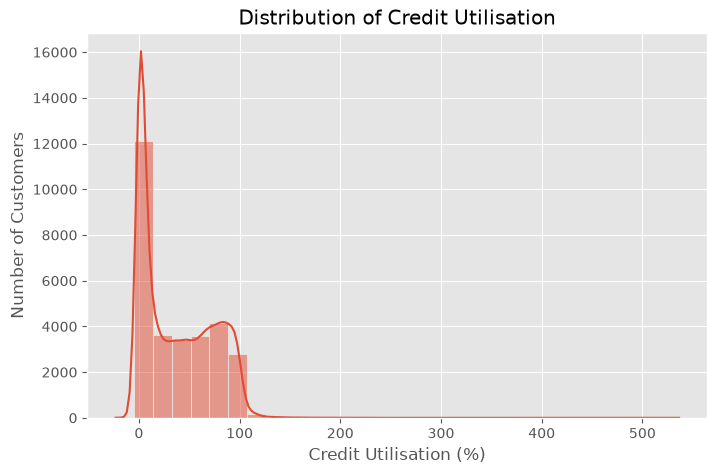

In [14]:
plt.figure(figsize=(8,5))

sns.histplot(
    df["credit_utilisation"],
    bins=30,
    kde=True
)

plt.title("Distribution of Credit Utilisation")
plt.xlabel("Credit Utilisation (%)")
plt.ylabel("Number of Customers")

plt.show()

## Credit Utilisation Distribution

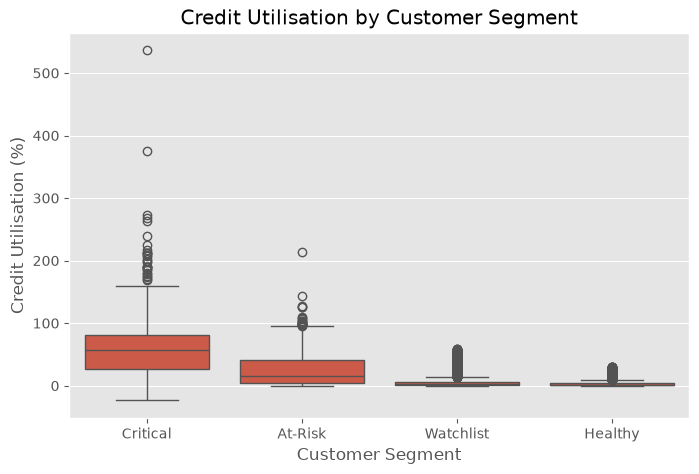

In [15]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x="segment",
    y="credit_utilisation"
)

plt.title("Credit Utilisation by Customer Segment")
plt.xlabel("Customer Segment")
plt.ylabel("Credit Utilisation (%)")

plt.show()

## Credit Utilisation by Customer Segment

In [16]:
exposure = df.groupby("segment")[[
    "credit_utilisation",
    "avg_bill_amt",
    "limit_balance"
]].mean()

print(exposure)

           credit_utilisation  avg_bill_amt  limit_balance
segment                                                   
At-Risk             25.051348  31666.012298  177530.864198
Critical            54.221805  63833.648623  139826.263682
Healthy              3.311578   6971.143042  237128.532361
Watchlist            5.757777   9625.323907  211906.532130


## Customer Exposure Analysis

In [17]:
default_rate = (
    df.groupby("segment")["default_next_month"]
      .mean() * 100
)

print(default_rate)

segment
At-Risk      15.963250
Critical     26.596961
Healthy      13.012762
Watchlist    16.595858
Name: default_next_month, dtype: float64


## Default Rate by Customer Segment

In [18]:
recommendations = pd.DataFrame({

    "Segment":[
        "Healthy",
        "Watchlist",
        "At-Risk",
        "Critical"
    ],

    "Recommendation":[
        "Reward, Cashback, Credit Limit Increase",
        "SMS Reminder, Email Reminder",
        "Credit Review, Installment Plan",
        "Immediate Intervention, Debt Restructuring"
    ]
})

recommendations

,Segment,Recommendation
0,Healthy,"Reward, Cashback, Credit Limit Increase"
1,Watchlist,"SMS Reminder, Email Reminder"
2,At-Risk,"Credit Review, Installment Plan"
3,Critical,"Immediate Intervention, Debt Restructuring"


## Customer Risk Recommendations